# Implementación de Quantum Circuit Learning para regresión de una función
(siguiendo el tutorial de QuLacs en https://docs.qulacs.org/en/latest/apply/5.2_qcl.html)

Ajuste de una función coseno:  $y=\cos(\pi x)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from qulacs import QuantumState, QuantumCircuit
from qulacsvis import circuit_drawer
from sklearn.model_selection import train_test_split

In [2]:
## seed of random number
random_seed = 0
## initialization of random number generator
np.random.seed(random_seed)

Suponemos que tenemos datos experimentales ruidosos y buscamos realizar un ajuste utilizando una función coseno. 

En este caso, generamos dichos datos "artificialmente" tomando 200 puntos al azar en el intervalo [-1,1] y aplicando ruido gaussiano sobre los mismos.

Separamos 100 datos para entrenamiento y 100 para testeo.

In [3]:
## Función que se busca aprender
func_to_learn = lambda x: np.cos(x*np.pi)

## Intervalo y número de datos total.
x_min = - 1.; x_max = 1.
num_x_data = 200

## Preparamos artificialmente los datos de entrenamiento
x_data = x_min + (x_max - x_min) * np.random.rand(num_x_data)
y_data = func_to_learn(x_data)

## Se agrega ruido para simular datos experimentales
mag_noise = 0.1
y_data = y_data + mag_noise * np.random.randn(num_x_data)

#Separo en conjuntos de entrenamiento y validación
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=0)
x_train, x_test, y_train,y_test = np.array(x_train), np.array(x_test), np.array(y_train), np.array(y_test)

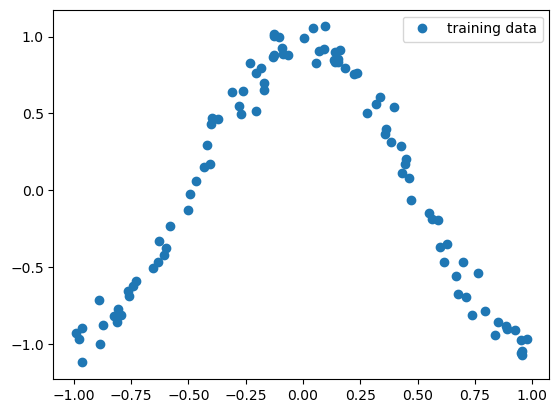

In [4]:
plt.plot(x_train, y_train, "o", label = 'training data'); plt.legend(); plt.show()

# Simulación de un circuito cuántico

Simularemos un circuito cuántico que "aprenda" a reproducir estos datos. Utilizaremos un sistema de 6 qubits y 6 capas. 

In [5]:
########  Parameter  #############
nqubit = 6 ## number of qubit
c_depth = 6 ## depth of circuit

### Librería qulacs

Para simular los comportamientos de sistemas cuánticos se utiliza la librería qulacs. 

Por ejemplo, en las siguientes líneas importamos las matrices de Pauli X y Z que son compuertas que actúan en un solo qubit.

In [6]:
## Basic gate
from qulacs.gate import X, Z
I_mat = np.eye(2, dtype=complex)
X_mat = X(0).get_matrix() # applied to qubit 0
Z_mat = Z(0).get_matrix() # applied to qubit 0

Definimos la función ```make_fullgate```  para crear operadores aplicables al sistema completo a partir de operadores o compuertas que actúan en un único spin o qubit. 

Estas funciones toman dos argumentos: ```list_SiteAndOperator``` y ```nqubit```.

```list_SiteAndOperator``` es una lista de listas, cada una de las cuales contiene un sitio y el operador que actúa en ese sitio.

```nqubit``` es el número de componentes del sistema. 

In [7]:
def make_fullgate(list_SiteAndOperator, nqubit):
    '''
    Toma list_SiteAndOperator = [ [i_0, O_0], [i_1, O_1], ...],
    Inserta una identidad si no hay operador actuando en algún sitio
    Genera matriz de tamaño: (2**nqubit, 2**nqubit):
    I(0) * ... * O_0(i_0) * ... * O_1(i_1) ...
    '''
    list_Site = [SiteAndOperator[0] for SiteAndOperator in list_SiteAndOperator]
    list_SingleGates = [] ## Producto tensorial de compuertas de 1 qb
    cnt = 0
    for i in range(nqubit):
        if (i in list_Site):
            list_SingleGates.append( list_SiteAndOperator[cnt][1] )
            cnt += 1
        else: 
            list_SingleGates.append(I_mat)

    return reduce(np.kron, list_SingleGates)

## Codificación de input en estado cuántico

Es necesario codificar el conjunto ${x_i}$ asociado a los tiempos en estados cuánticos. Para eso, creamos la compuerta $U_{in}(x_i)$ que transformará los estados $\ket{00...0}$ usando compuertas de rotación. Siguiendo el trabajo de referencia, definimos:

$U_{in}(\mathbf{x_{i}}) \ =\ \prod _{j} R_{j}^{Z}\left(\cos^{-1} x_{i}^{2}\right) R_{j}^{Y}\left(\sin^{-1} x_{i}\right)$

De esta forma el input $x_i$, se codifica según: $\ket{\psi_{in}(x_i)} = U_{in}(x_i)\ket{00...0}$

In [8]:
# Function that creats a gate encoding x
def U_in(x):
    U = QuantumCircuit(nqubit)

    angle_y = np.arcsin(x)
    angle_z = np.arccos(x**2)

    for i in range(nqubit):
        U.add_RY_gate(i, angle_y)
        U.add_RZ_gate(i, angle_z)

    return U

En el siguiente ejemplo, podemos ver cómo codificamos el valor $x=0.1$ en un estado inicializado como $\ket{000000}$

In [9]:
# Estado Inicial
state = QuantumState(nqubit) # Estado Inicial |000000>
state.set_zero_state()
print(state.get_vector())

[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [10]:
# Codificación de x en el estado cuántico
x = 0.1 
U_in(x).update_quantum_state(state) # Calculamos U_in|000>
print( [f"{num:.2E}" for num in state.get_vector()])

['-2.98E-02-9.92E-01j', '4.97E-02-9.95E-04j', '4.97E-02-9.95E-04j', '2.49E-05+2.49E-03j', '4.97E-02-9.95E-04j', '2.49E-05+2.49E-03j', '2.49E-05+2.49E-03j', '-1.25E-04+1.36E-20j', '4.97E-02-9.95E-04j', '2.49E-05+2.49E-03j', '2.49E-05+2.49E-03j', '-1.25E-04+1.36E-20j', '2.49E-05+2.49E-03j', '-1.25E-04-1.36E-20j', '-1.25E-04-1.36E-20j', '6.27E-08-6.27E-06j', '4.97E-02-9.95E-04j', '2.49E-05+2.49E-03j', '2.49E-05+2.49E-03j', '-1.25E-04+2.71E-20j', '2.49E-05+2.49E-03j', '-1.25E-04-2.71E-20j', '-1.25E-04-2.71E-20j', '6.27E-08-6.27E-06j', '2.49E-05+2.49E-03j', '-1.25E-04+0.00E+00j', '-1.25E-04+0.00E+00j', '6.27E-08-6.27E-06j', '-1.25E-04+0.00E+00j', '6.27E-08-6.27E-06j', '6.27E-08-6.27E-06j', '3.14E-07+6.28E-09j', '4.97E-02-9.95E-04j', '2.49E-05+2.49E-03j', '2.49E-05+2.49E-03j', '-1.25E-04+0.00E+00j', '2.49E-05+2.49E-03j', '-1.25E-04-1.36E-20j', '-1.25E-04-1.36E-20j', '6.27E-08-6.27E-06j', '2.49E-05+2.49E-03j', '-1.25E-04+0.00E+00j', '-1.25E-04+0.00E+00j', '6.27E-08-6.27E-06j', '-1.25E-04+0.00

La librería qulacs_viz nos permite visualizar la compuerta de entrada obtenida

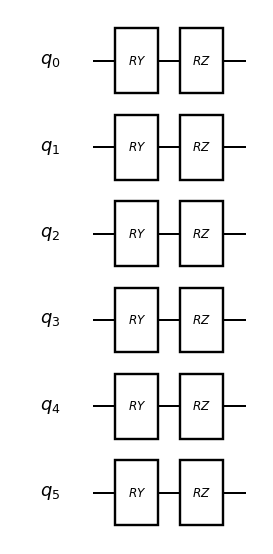

In [11]:
circuit_drawer(U_in(x),'mpl')

## Circuito Cuántico Parametrizado

A continuación, generamos el circuito cuántico que vamos a optimizar. 

El mismo consiste de 6 capas. En cada una, aplicaremos una compuerta de Haddammard a cada qubit,  $N_{qubits} - 1$ compuertas CNOT y tres compuertas de rotación parametrizadas según:

$U_{rot}(\theta_j^{(i)}) = R^X_j(\theta^{(i)}_{j1})R^Z_j(\theta^{(i)}_{j2})R^X_j(\theta^{(i)}_{j3})$

En total se tienen $3 \times N_{qubits} \times d$ parametros. 

Los valores iniciales para $\theta$ se eligen aleatoriamente de una distribución uniforme en $\left[ 0,2 \pi \right]$ 

La clase ```ParametricQuantumCircuit``` de qulacs permite crear un circuito cuántico con compuertas que dependen de parámetros que pueden ser actualizados. 

In [12]:
from qulacs import ParametricQuantumCircuit

U_out = ParametricQuantumCircuit(nqubit)

In [13]:
for d in range(c_depth):

    for i in range(nqubit):
        U_out.add_H_gate(i)
        if i > 0:
            U_out.add_CNOT_gate(i, i - 1)  # control, objetivo

    for i in range(nqubit):
        angle = 2.0 * np.pi * np.random.rand()
        U_out.add_parametric_RX_gate(i, angle)

        angle = 2.0 * np.pi * np.random.rand()
        U_out.add_parametric_RZ_gate(i, angle)

        angle = 2.0 * np.pi * np.random.rand()
        U_out.add_parametric_RX_gate(i, angle)

De esta forma, el circuito variacional completo $U(\theta)$ es:

$U\left(\{ \theta^{(i)}_{j} \} \right) = \prod\limits_{i=1}^d \left( \left( \prod\limits_{j=1}^n U_{rot}(\theta_j^{(i)}) \right) . \prod\limits_{j=1}^{n-1} U_{CNOT} \right)$

Usando qulacs_viz nuevamente podemos ver el circuito resultante.

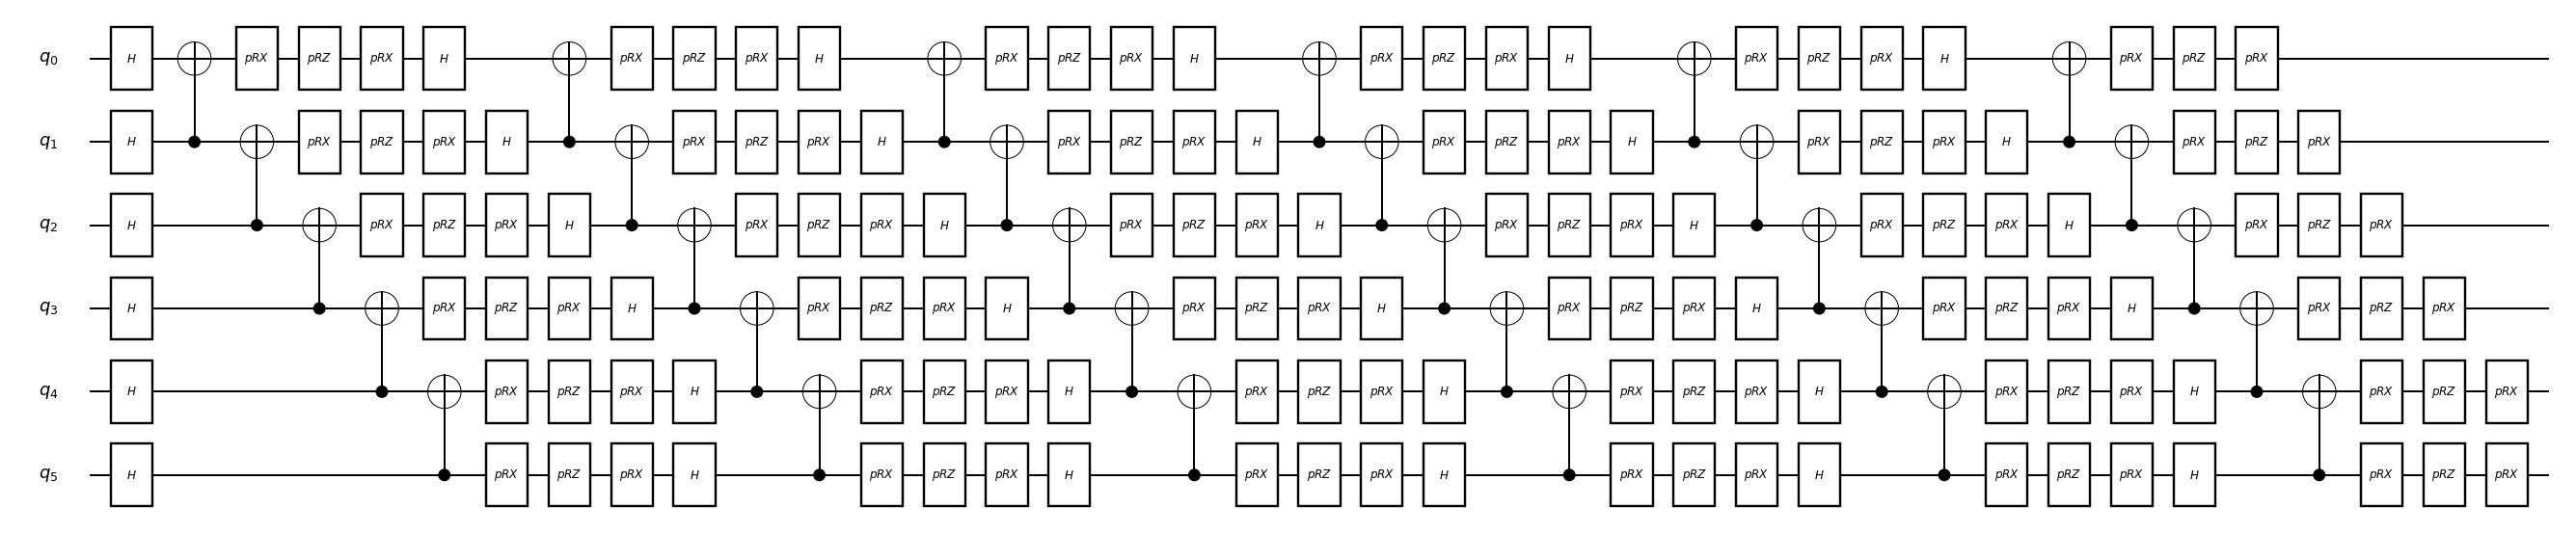

In [14]:
circuit_drawer(U_out,'mpl')

Es posible acceder a los parámetros iniciales del circuito definido

In [15]:
# Acceder a valores de los parámetros
parameter_count = U_out.get_parameter_count()
theta_init = [U_out.get_parameter(ind) for ind in range(parameter_count)]
print('Initial parameters:', theta_init)

Initial parameters: [2.8229826856732885, 1.9130314237335426, 5.272780762920498, 1.493775948123507, 3.156606057778451, 5.922427424410481, 3.9835250192549365, 5.449340049474277, 5.907511705821757, 4.717194749351038, 4.395559739673432, 6.081907025943442, 6.2480044309620775, 2.838879358015791, 0.4452879490100944, 1.839679156376946, 0.9572728482568181, 2.6231442560659715, 0.8249151796526367, 3.7957841100296026, 2.405253972770563, 5.625875432415682, 6.080833262211037, 3.436179178887666, 1.7267674162587254, 3.7210934656291865, 5.63451653340496, 2.555580982495167, 3.4688101165240175, 1.7068446780776063, 2.861639988065313, 2.524040583192261, 1.5608278339148927, 3.1784522302472467, 1.950180245426615, 2.3438471758012493, 3.2984865694755627, 4.716127619709539, 2.0954892088944397, 5.80666078393279, 5.418107223587794, 0.3059301522756663, 1.5936829816864106, 2.80315209815133, 0.6573964132679336, 2.1895392142001433, 4.65016989884099, 4.275798589239543, 3.9105566969832846, 4.464381620318822, 1.28757349

Luego, definimos una función  ```set_U_out``` que permite actualizar $\theta$ en $U(\theta)$ 

In [16]:
# Function that updates parameter theta
def set_U_out(theta):
    global U_out

    parameter_count = U_out.get_parameter_count()

    for i in range(parameter_count):
        U_out.set_parameter(i, theta[i])

## Medida

Se toma como output del modelo el valor de expectación de la magnetización del primer qubit para el estado de salida $\ket{\psi_{out}}$, es decir:

$y(\theta,x_i)=\left<\psi_\text{out}|Z_0|\psi_\text{out}\right> $

In [17]:
# Create observable Z_0
from qulacs import Observable

obs = Observable(nqubit)
obs.add_operator(2.,'Z 0')

### Repaso

Hasta ahora tenemos:
- Datos Etiquetados de entrenamiento y su compuerta de codificación
- Circuito Parametrizado inicializado al azar
- Operadores de medición definidos

$\to$ Ya podemos empezar la optimización!

### Cálculo de $y(\theta \ , x_i)$

Definimos la función ```qcl_pred``` para calcular para cada entrada las predicciones provistas por $U_{out}$ para cada conjunto de parámetros ($\mathbf{\theta}$). 
1. Inicializamos el estado en $\ket{000000}$
2. Codificamos el valor $x$ de la entrada usando $U_{in}$
3. Aplicamos el circuito parametrizado $U_{out}$
4. Medimos usando la función ```get_output```

In [18]:
# Function that gives prediction value y(x_i, theta) of the model from input x_i
def qcl_pred(x, U_out):
    state = QuantumState(nqubit)
    state.set_zero_state()

    # Calculate input state
    U_in(x).update_quantum_state(state)

    # Calculate output state
    U_out.update_quantum_state(state)

    # Output of the model
    res = obs.get_expectation_value(state)

    return res

### Función costo
Utilizamos como función perdida el error cuadrático medio. Esta será la función que minimizaremos 

In [19]:
# Calculate cost function L
def cost_func(theta):
    '''
    theta: ndarray of length c_depth * nqubit * 3
    '''
    # update the parameter theta of U_out
    # global U_out
    set_U_out(theta)

    # calculate basing on data of num_x_train in total
    y_pred = [qcl_pred(x, U_out) for x in x_train]

    # quadratic loss
    L = ((y_pred - y_train)**2).mean()

    return L

# Resultados

Minimizamos usando el método de Nelder-Mead a través de la función minimize de scipy.

In [20]:
from scipy.optimize import minimize
result = minimize(cost_func, theta_init, method='Nelder-Mead')


KeyboardInterrupt: 

In [ ]:
# Función costo luego de optimizar
result.fun

NameError: name 'result' is not defined

In [ ]:
# Parámetros optimizados
theta_opt = result.x
print(theta_opt)

NameError: name 'result' is not defined

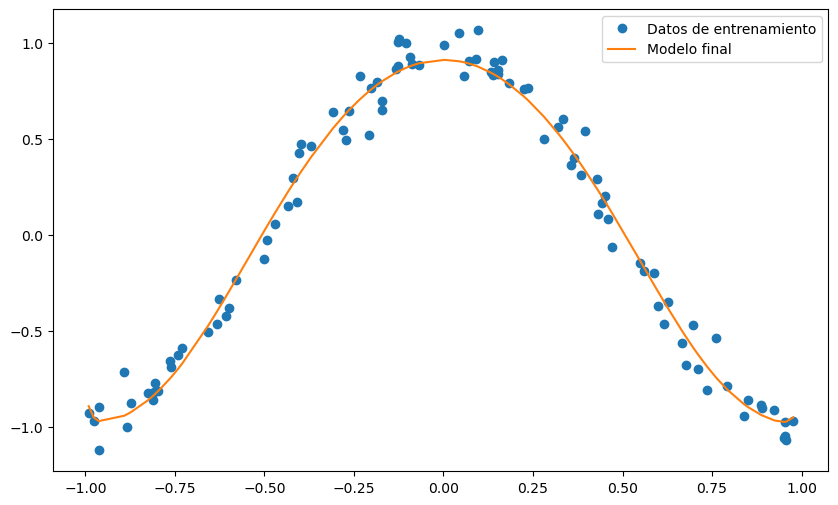

In [21]:
# Insert optimized theta into U_out
#set_U_out(theta_opt)
# Plot
plt.figure(figsize=(10, 6))
xlist = np.arange(x_min, x_max, 0.02)

# teacher data
plt.plot(x_train, y_train, "o", label='Datos de entrenamiento')

# Figure basing on inital parameter theta
#plt.plot(xlist, y_init, '--', label='Initial Model Prediction', c='gray')

# Prediction of the model
y_pred = np.array([qcl_pred(x, U_out) for x in np.sort(x_train)])
plt.plot(np.sort(x_train), y_pred, label='Modelo final')

plt.legend()
plt.show()

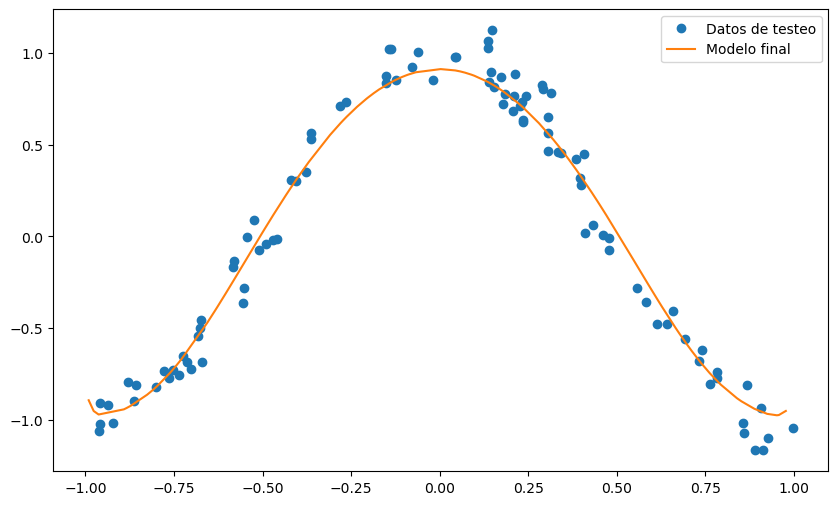

In [22]:
# Insert optimized theta into U_out
#set_U_out(theta_opt)
# Plot
plt.figure(figsize=(10, 6))
xlist = np.arange(x_min, x_max, 0.02)

# teacher data
plt.plot(x_test, y_test, "o", label='Datos de testeo')

# Figure basing on inital parameter theta
#plt.plot(xlist, y_init, '--', label='Initial Model Prediction', c='gray')

# Prediction of the model
y_pred = np.array([qcl_pred(x, U_out) for x in np.sort(x_train)])
plt.plot(np.sort(x_train), y_pred, label='Modelo final')

plt.legend()
plt.show()

### Benchmarking

Calculamos distintas métricas sobre el conjunto de testeo para chequear la precisión del método utilizado.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = np.array([qcl_pred(x, U_out) for x in x_test])

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r_squared)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.09058162743183677
Mean Squared Error (MSE): 0.01303667729833999
R-squared (R²): 0.9747426088557384
Root Mean Squared Error (RMSE): 0.11417826981672122


In [24]:
y_pred = np.array([qcl_pred(x, U_out) for x in x_train])

# Calculate evaluation metrics
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
r_squared = r2_score(y_train, y_pred)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r_squared)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.07257425236528638
Mean Squared Error (MSE): 0.008251362621424176
R-squared (R²): 0.9837858660124147
Root Mean Squared Error (RMSE): 0.09083701129729102


In [25]:
class Perceptron:
    def __init__(self, input_size, learning_rate=0.01, epochs=1000):
        self.weights = np.zeros(input_size)
        self.bias = 0.01
        self.learning_rate = learning_rate
        self.epochs = epochs

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def fit(self, X, y):
        for _ in range(self.epochs):
            for i in range(X.shape[0]):
                y_pred = self.predict(X[i])
                error = y[i] - y_pred
                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error

    def mean_squared_error(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

In [27]:
from sklearn.neural_network import MLPRegressor

x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

# Define the neural network model
model = MLPRegressor(hidden_layer_sizes=(18,6), activation='relu', solver='adam', max_iter=1000, random_state=0)


# Train the model
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r_squared)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 0.11578221837289959
Mean Squared Error (MSE): 0.019645956799838642
R-squared (R²): 0.9619377235516925
Root Mean Squared Error (RMSE): 0.1401640353294619


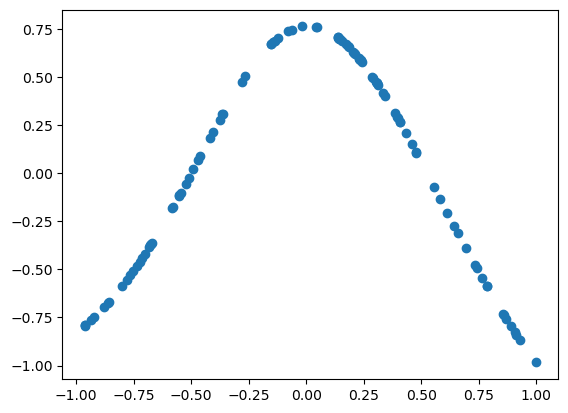

In [ ]:
plt.scatter(x_test, y_pred, label='Modelo final')
